In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(Path.cwd())

d:\Anisha\Projects\EuroSAT\notebooks


In [2]:
from src.models import resnet18_rgb_model
from src.evaluation import *
from src.visualisation import *
from src.dataloader import *
from src.train import *
from src.config import *
from src.utils import *
import torch.nn as nn

create_dirs()
torch.cuda.empty_cache()

In [ ]:
create_dirs()

from src.visualisation import *
from src.utils import *
from src.train import *
from src.dataloader import *

importlib.reload(src.dataloader)
importlib.reload(src.train)
importlib.reload(src.datasets)
importlib.reload(src.config)
importlib.reload(src.utils)
importlib.reload(src.visualisation)
importlib.reload(src.evaluation)

NameError: name 'create_dirs' is not defined

In [4]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.zeros(1, device="cuda"))

True
NVIDIA GeForce RTX 2060
tensor([0.], device='cuda:0')


### Load Data

In [5]:
train_loader, val_loader, test_loader = load_rgb_data()

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

287
51
85


### Load Model

In [6]:
model = resnet18_rgb_model()

DEVICE = get_device()
print(DEVICE)

model = model.to(DEVICE)

print(model.fc)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
cuda
Linear(in_features=512, out_features=10, bias=True)


### Loss Fn and Optimizer

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 1e-4
)

print('Loss Function : ', criterion)
print('Optimizer : ', optimizer)

Loss Function :  CrossEntropyLoss()
Optimizer :  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


### Training Loop

In [9]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.zeros(1, device="cuda"))

True
NVIDIA GeForce RTX 2060
tensor([0.], device='cuda:0')


In [10]:
train_loader, val_loader, test_loader = load_rgb_data()

history = training_loop(train_loader, val_loader, model, criterion, optimizer, 'rgb_resnet18_v1.pth')

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Epoch [1/20] Train Loss : 0.4203 Train ACC : 0.8631 Val Loss : 0.1911 Val ACC : 0.9380 LR : 0.000100
Epoch [2/20] Train Loss : 0.1908 Train ACC : 0.9347 Val Loss : 0.1531 Val ACC : 0.9469 LR : 0.000100
Epoch [3/20] Train Loss : 0.1512 Train ACC : 0.9486 Val Loss : 0.1153 Val ACC : 0.9617 LR : 0.000100
Epoch [4/20] Train Loss : 0.1186 Train ACC : 0.9591 Val Loss : 0.1420 Val ACC : 0.9531 LR : 0.000100
Epoch [5/20] Train Loss : 0.1091 Train ACC : 0.9624 Val Loss : 0.0961 Val ACC : 0.9611 LR : 0.000100
Epoch [6/20] Train Loss : 0.0972 Train ACC : 0.9676 Val Loss : 0.0900 Val ACC : 0.9716 LR : 0.000100
Epoch [7/20] Train Loss : 0.0954 Train ACC : 0.9668 Val Loss : 0.0855 Val ACC : 0.9685 LR : 0.000100
Epoch [8/20] Train Loss : 0.0784 Train ACC : 0.9741 Val Loss : 0.0801 Val ACC : 0.9738 LR : 0.000100
Epoch [9/20] Train Loss : 0.0756 Train ACC : 0.9736 Val Loss : 0.0868 Val ACC : 0.9707 LR : 0.000100
Epoch [10/20] Train Loss : 0.0663 Train

In [ ]:
# history["lr"] = [None] * len(history["train_loss"])

# for key, value in history.items():
#     print(key, len(value))

train_loss 20
train_acc 20
val_loss 20
val_acc 20
lr 20


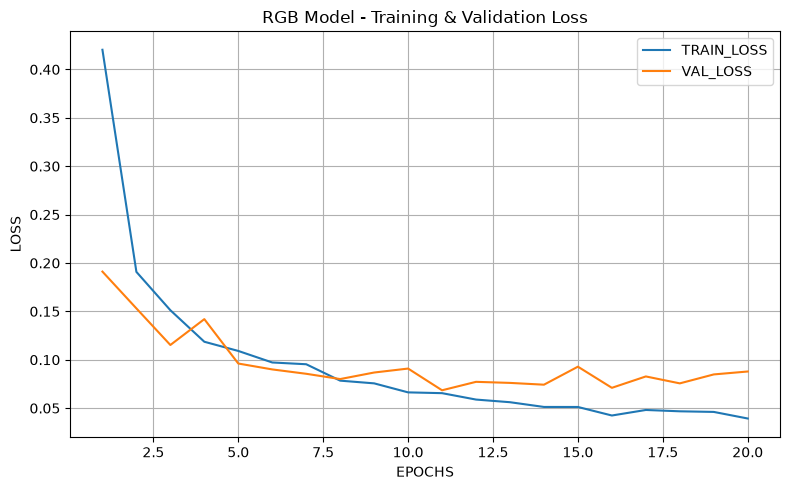

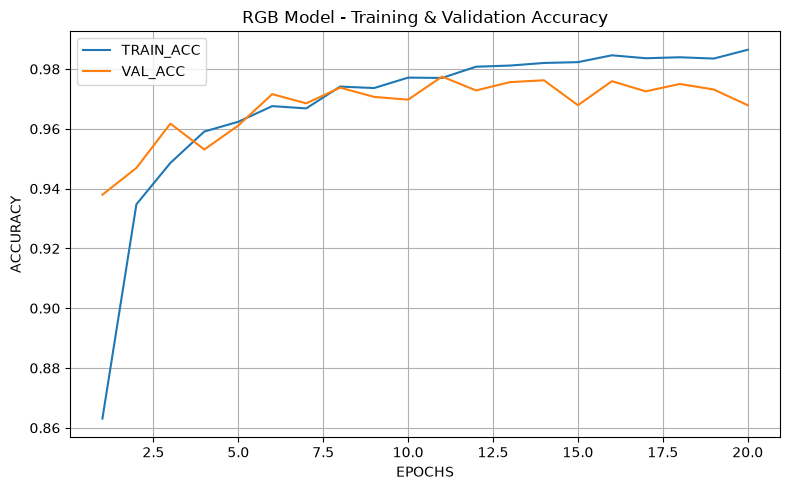

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
   accuracy  macro_precision  macro_recall  macro_f1
0  0.967222         0.967352      0.965617  0.966263
                      precision    recall  f1-score      support
AnnualCrop             0.962901  0.951667  0.957251   600.000000
Forest                 0.990066  0.996667  0.993355   600.000000
HerbaceousVegetation   0.932177  0.985000  0.957861   600.000000
Highway                0.969940  0.968000  0.968969   500.000000
Industrial             0.981481  0.954000  0.967546   500.000000
Pasture                0.952970  0.962500  0.957711   400.000000
PermanentCrop          0.949896  0.910000  0.929520   500.000000
Residential            0.953674  0.995000  0.973899   600.000000
River                  0.985477  0.950000  0.967413   500.000000
SeaLake                0.994941  0.983333  0.989103   600.000000
accuracy               0.967222  0.967222  0.967222     0.967222
macro avg              0.967352  0.965617  0.966263  5400.0000

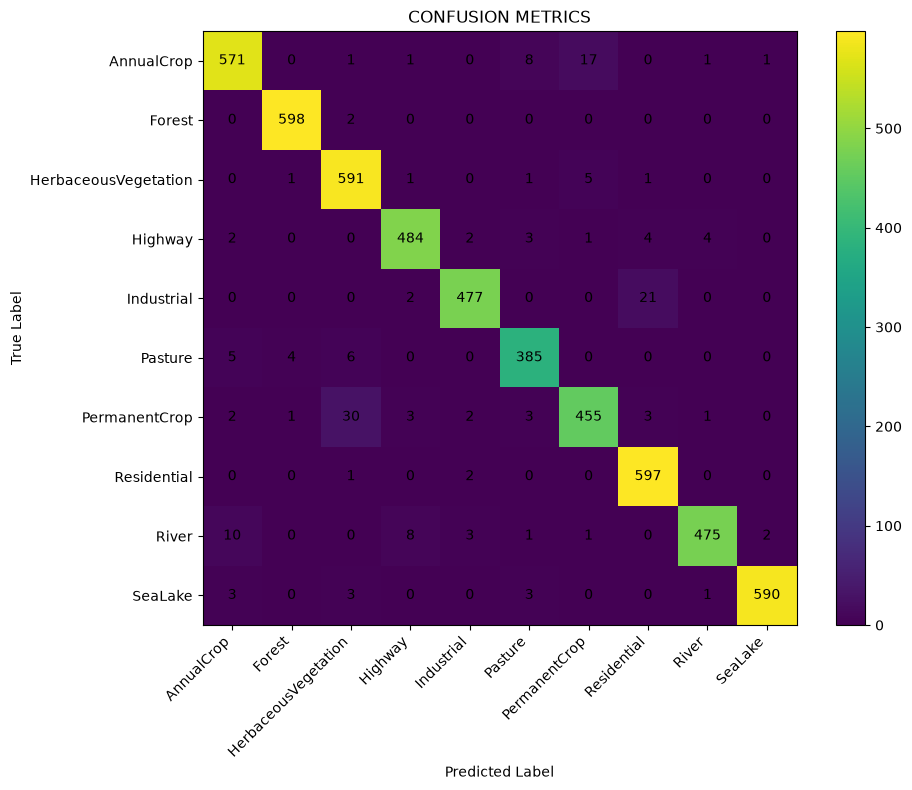

In [12]:
plot_all_evaluation(history, model, test_loader, 'rgb')

In [ ]:
from deployment.mlflow_logs import log_metrics_history

model_name = 'rgb_resnet18_v1'
method = 'RGB'
path = 'RGB_v1/rgb_model_history.csv'
version = 'v1'

log_metrics_history(model_name, path, method, version)


# RGB Model V2 

- Adding Learning Rate Scheduler 

In [13]:
model = resnet18_rgb_model()

model = model.to(get_device())

print(model.fc)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 1e-4
)

print('Loss Function : ', criterion)
print('Optimizer : ', optimizer)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Linear(in_features=512, out_features=10, bias=True)
Loss Function :  CrossEntropyLoss()
Optimizer :  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [14]:
train_loader, val_loader, test_loader = load_rgb_data()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.2, patience=5,  min_lr=1e-6
)

history = training_loop(train_loader, val_loader, model, criterion, optimizer, 'rgb_resnet18_v2.pth', scheduler)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Epoch [1/20] Train Loss : 0.4209 Train ACC : 0.8635 Val Loss : 0.1898 Val ACC : 0.9370 LR : 0.000100
Epoch [2/20] Train Loss : 0.1951 Train ACC : 0.9336 Val Loss : 0.1428 Val ACC : 0.9531 LR : 0.000100
Epoch [3/20] Train Loss : 0.1468 Train ACC : 0.9502 Val Loss : 0.1137 Val ACC : 0.9602 LR : 0.000100
Epoch [4/20] Train Loss : 0.1214 Train ACC : 0.9594 Val Loss : 0.1126 Val ACC : 0.9611 LR : 0.000100
Epoch [5/20] Train Loss : 0.1111 Train ACC : 0.9614 Val Loss : 0.1076 Val ACC : 0.9617 LR : 0.000100
Epoch [6/20] Train Loss : 0.0932 Train ACC : 0.9688 Val Loss : 0.0935 Val ACC : 0.9660 LR : 0.000100
Epoch [7/20] Train Loss : 0.0945 Train ACC : 0.9696 Val Loss : 0.0935 Val ACC : 0.9670 LR : 0.000100
Epoch [8/20] Train Loss : 0.0782 Train ACC : 0.9731 Val Loss : 0.0943 Val ACC : 0.9657 LR : 0.000100
Epoch [9/20] Train Loss : 0.0729 Train ACC : 0.9740 Val Loss : 0.0869 Val ACC : 0.9676 LR : 0.000100
Epoch [10/20] Train Loss : 0.0661 Train

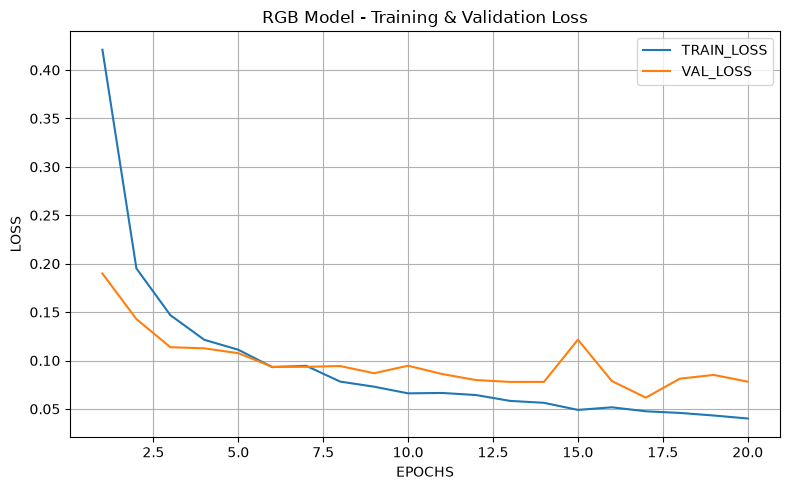

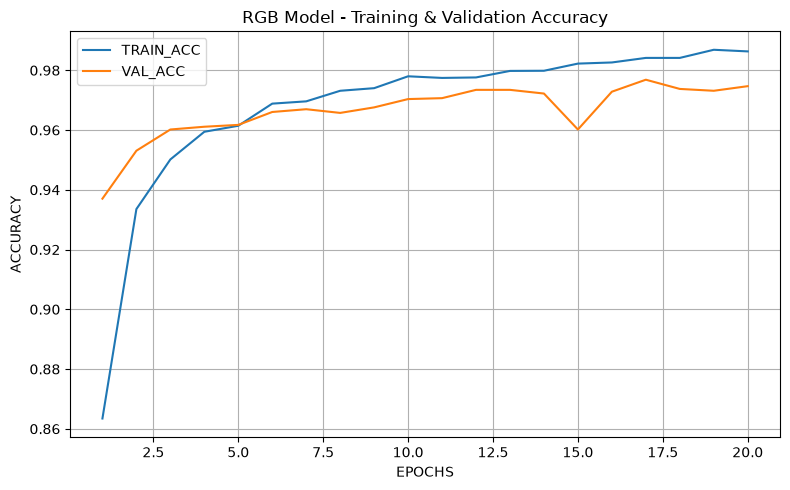

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
   accuracy  macro_precision  macro_recall  macro_f1
0  0.974074         0.973448      0.972967  0.973158
                      precision    recall  f1-score      support
AnnualCrop             0.959083  0.976667  0.967795   600.000000
Forest                 0.986777  0.995000  0.990871   600.000000
HerbaceousVegetation   0.963516  0.968333  0.965919   600.000000
Highway                0.962151  0.966000  0.964072   500.000000
Industrial             0.968442  0.982000  0.975174   500.000000
Pasture                0.972010  0.955000  0.963430   400.000000
PermanentCrop          0.959184  0.940000  0.949495   500.000000
Residential            0.998296  0.976667  0.987363   600.000000
River                  0.968379  0.980000  0.974155   500.000000
SeaLake                0.996644  0.990000  0.993311   600.000000
accuracy               0.974074  0.974074  0.974074     0.974074
macro avg              0.973448  0.972967  0.973158  5400.0000

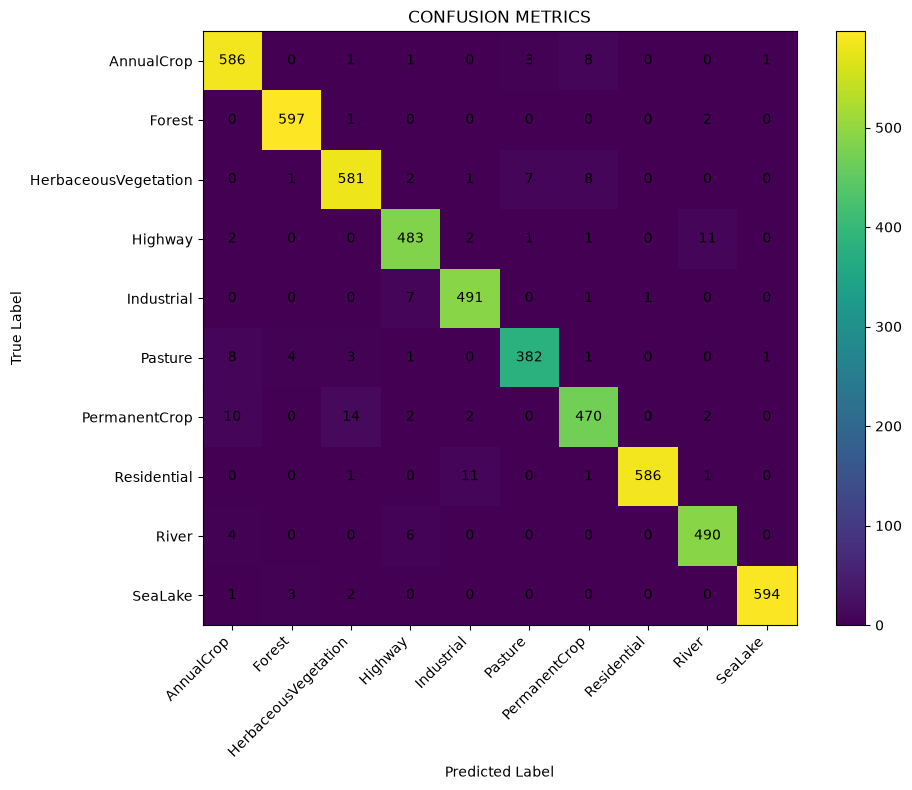

In [16]:
plot_all_evaluation(history, model, test_loader, 'rgb')